# A Comparative Study of Explainable Machine Learning Models for Heart Disease Risk Prediction

## Objective
The goal of this project is to predict the presence of heart disease using machine learning models based on clinical features.



# Exploratory Data Analysis (EDA)

This section presents an exploratory analysis of the UCI Heart Disease dataset.
The objective of the EDA is to understand the structure, quality, and key
characteristics of the data before applying machine learning models.

The analysis focuses on:
- Dataset structure and missing values
- Target variable distribution
- Univariate and bivariate feature analysis
- Correlation and outlier detection

These insights guide preprocessing decisions and model selection in later stages.


##Import Libraries

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import precision_score, recall_score, f1_score


## Dataset Description

The dataset used in this study is the Cleveland Heart Disease dataset obtained
from the UCI Machine Learning Repository. It contains clinical measurements
related to cardiovascular health and is widely used in medical machine learning
research.


## Feature Description

- age: Age of patient
- sex: Gender (1 = male, 0 = female)
- cp: Chest pain type
- trestbps: Resting blood pressure
- chol: Cholesterol level
- thalach: Maximum heart rate achieved
- exang: Exercise induced angina
- oldpeak: ST depression
- target: Heart disease (1 = yes, 0 = no)

In [62]:
column_names = [
    "age", "sex", "cp", "trestbps", "chol",
    "fbs", "restecg", "thalach", "exang",
    "oldpeak", "slope", "ca", "thal", "target"
]

df = pd.read_csv(
    "/content/drive/MyDrive/processed.cleveland.data",
    names=column_names,
    na_values="?"
)

df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## Data Structure and Overview

This subsection examines the number of observations, feature types,
and potential missing values in the dataset.


In [63]:
print("Dataset shape:", df.shape)
df.info()


Dataset shape: (303, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


## Missing Values

Identifying missing values is essential, as they can influence model
performance and preprocessing decisions.


ca      4
thal    2
dtype: int64
Total missing values in dataset: 6


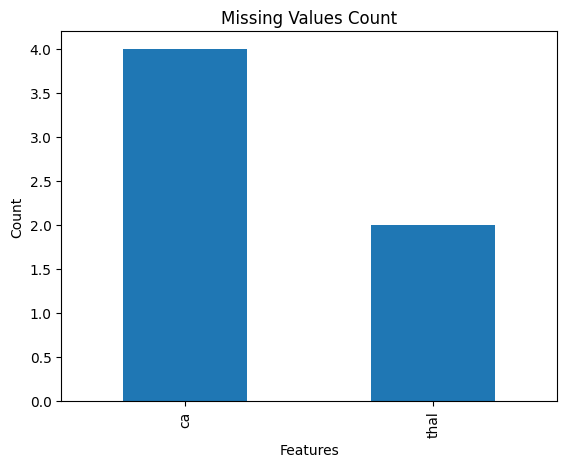

In [64]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
print(missing_values)
total_missing = df.isnull().sum().sum()
print("Total missing values in dataset:", total_missing)
missing_values.plot(kind='bar')
plt.title("Missing Values Count")
plt.ylabel("Count")
plt.xlabel("Features")
plt.show()

## Target Variable

In the original dataset, the target variable ranges from 0 to 4.
For binary classification, the target is converted into:
- 0: No heart disease
- 1: Presence of heart disease

This transformation is consistent with existing literature.


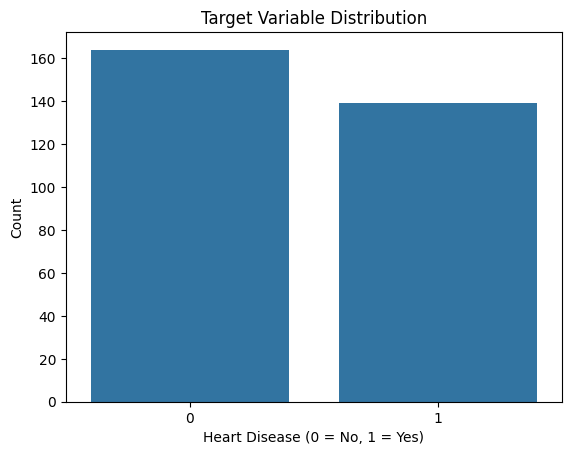

In [65]:
df["target"] = df["target"].apply(lambda x: 1 if x > 0 else 0)
df["target"].value_counts()
sns.countplot(x="target", data=df)
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.title("Target Variable Distribution")
plt.show()

## Summary Statistics

Descriptive statistics provide insight into the range, central tendency,
and variability of numerical clinical features.


In [66]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


## Univariate Analysis

This section examines the distribution of key numerical features
to identify skewness, spread, and potential anomalies.


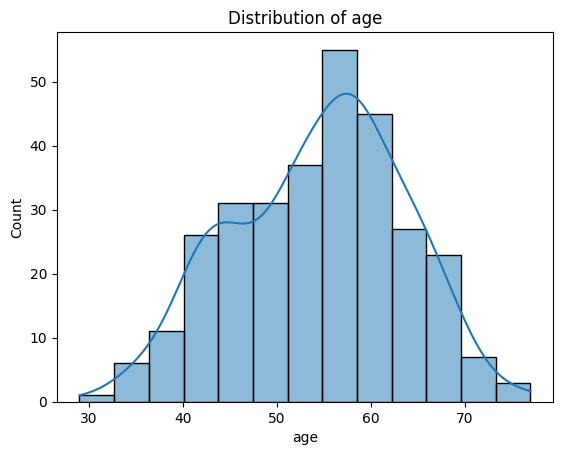

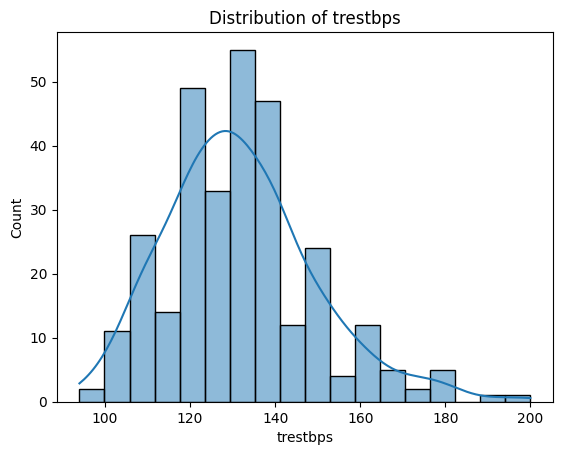

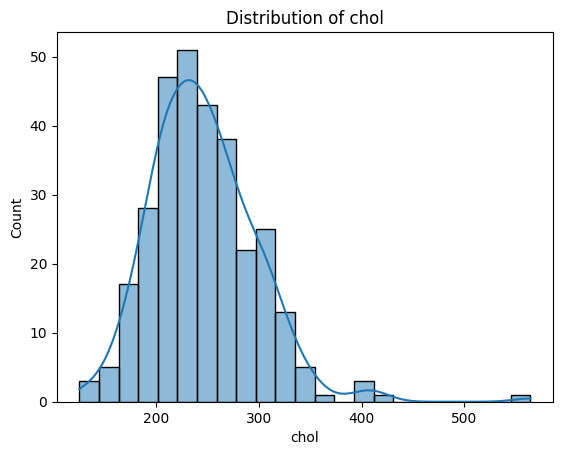

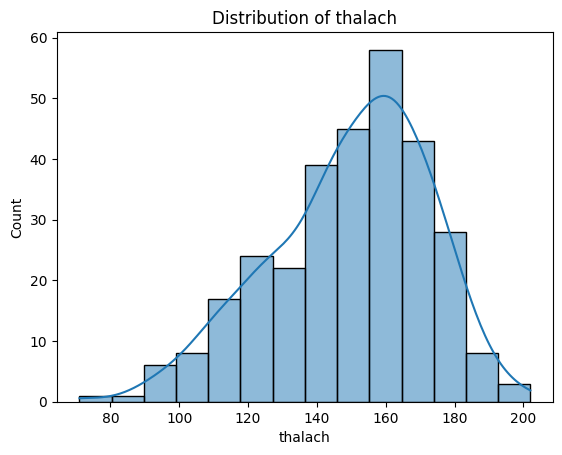

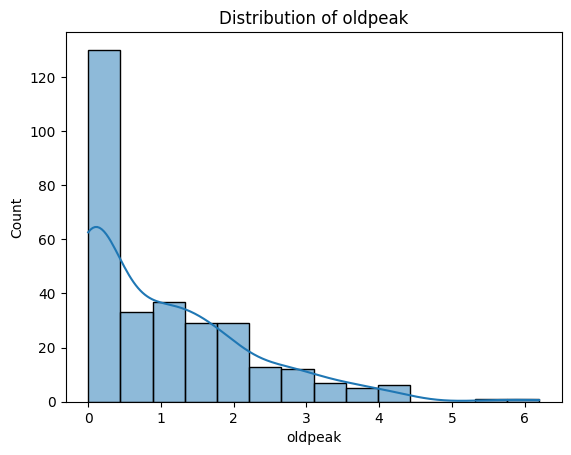

In [67]:
numerical_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

for col in numerical_features:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


## Bivariate Analysis

Bivariate analysis explores the relationship between individual
features and the target variable to identify discriminative patterns.


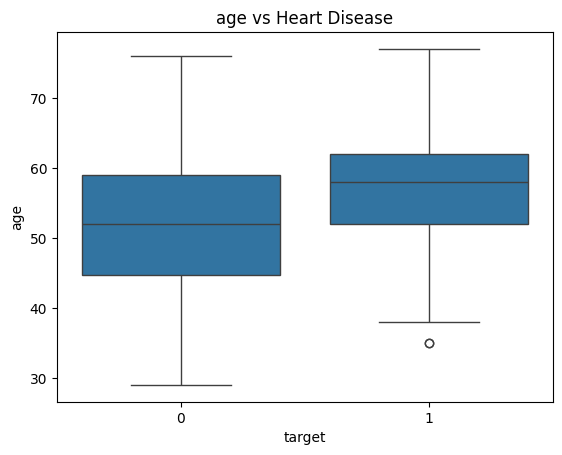

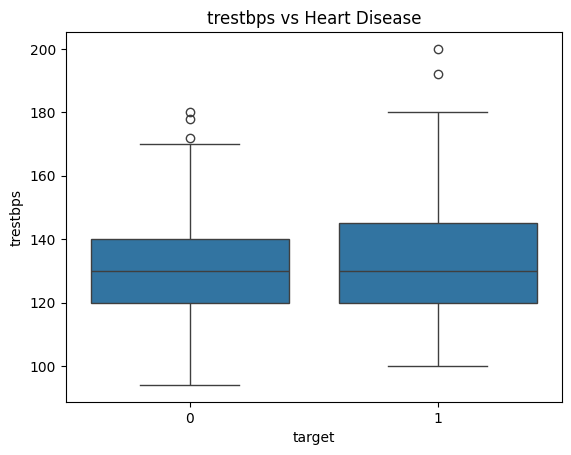

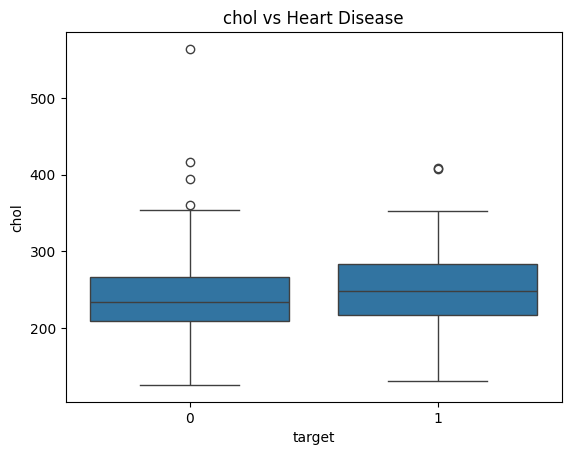

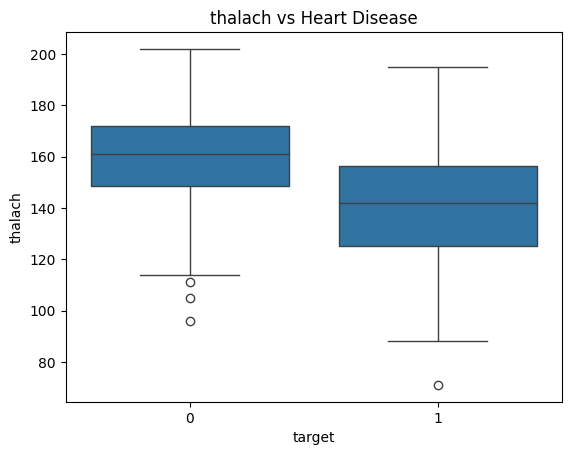

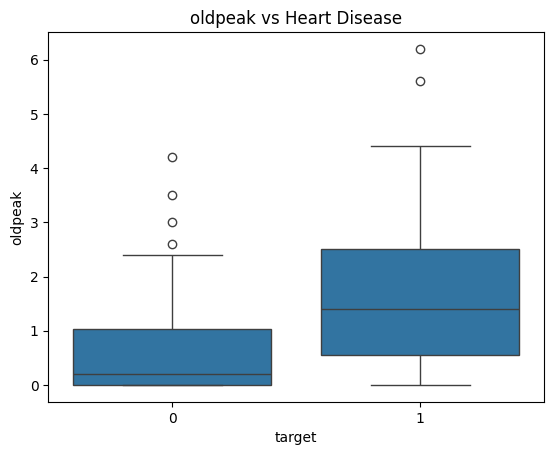

In [68]:
for col in numerical_features:
    plt.figure()
    sns.boxplot(x="target", y=col, data=df)
    plt.title(f"{col} vs Heart Disease")
    plt.show()


## Categorical Features

Categorical variables are analysed to understand how their distributions
vary between patients with and without heart disease.


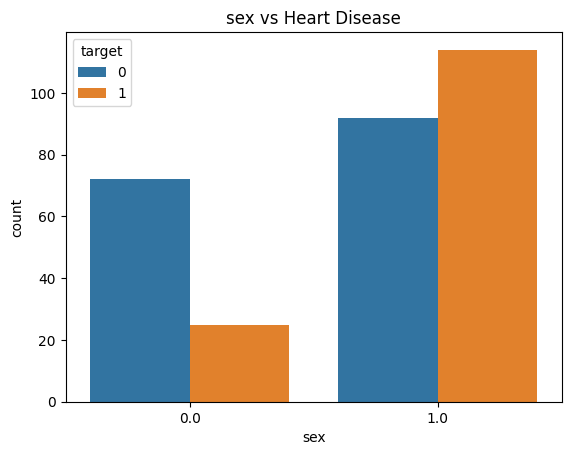

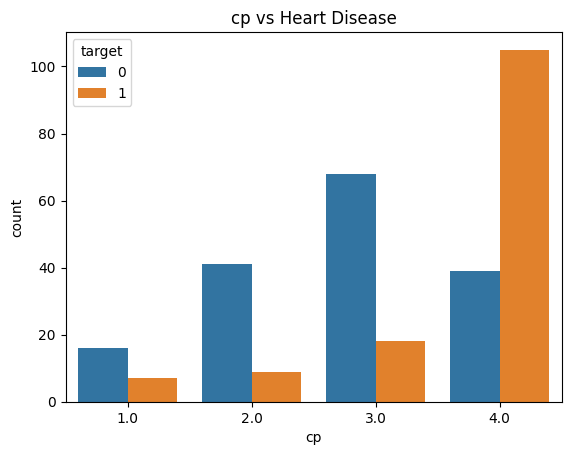

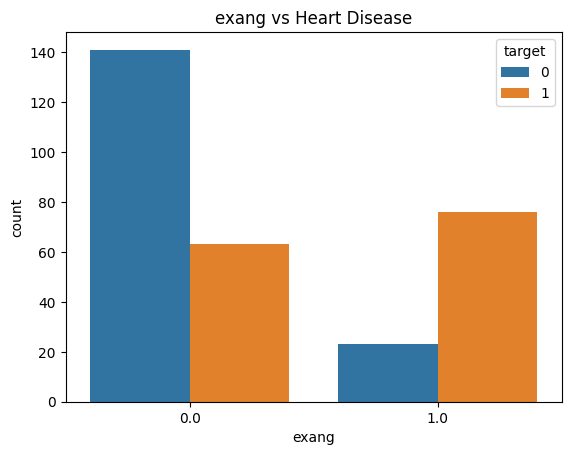

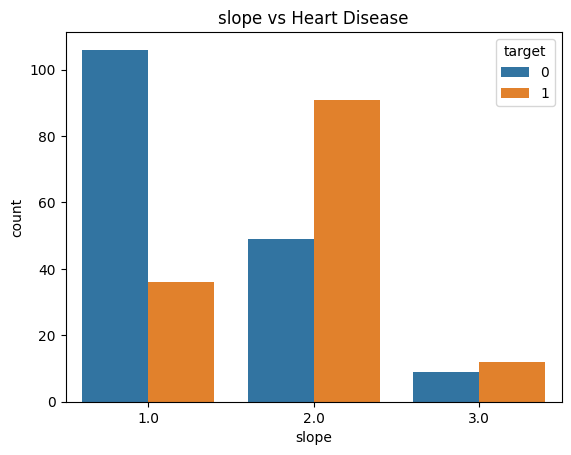

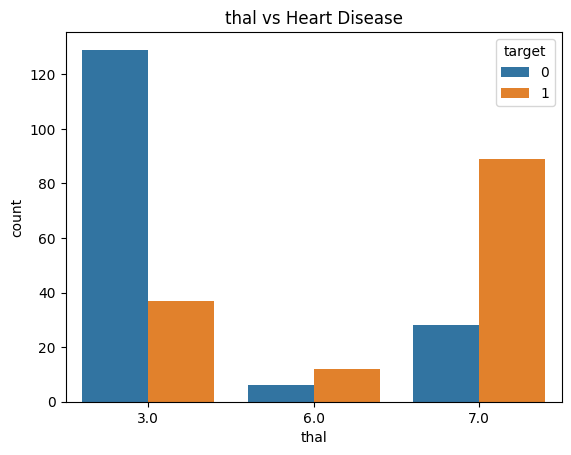

In [69]:
categorical_features = ["sex", "cp", "exang", "slope", "thal"]

for col in categorical_features:
    plt.figure()
    sns.countplot(x=col, hue="target", data=df)
    plt.title(f"{col} vs Heart Disease")
    plt.show()


## Correlation Analysis

Correlation analysis is performed to identify linear relationships
between numerical features and assess potential multicollinearity.


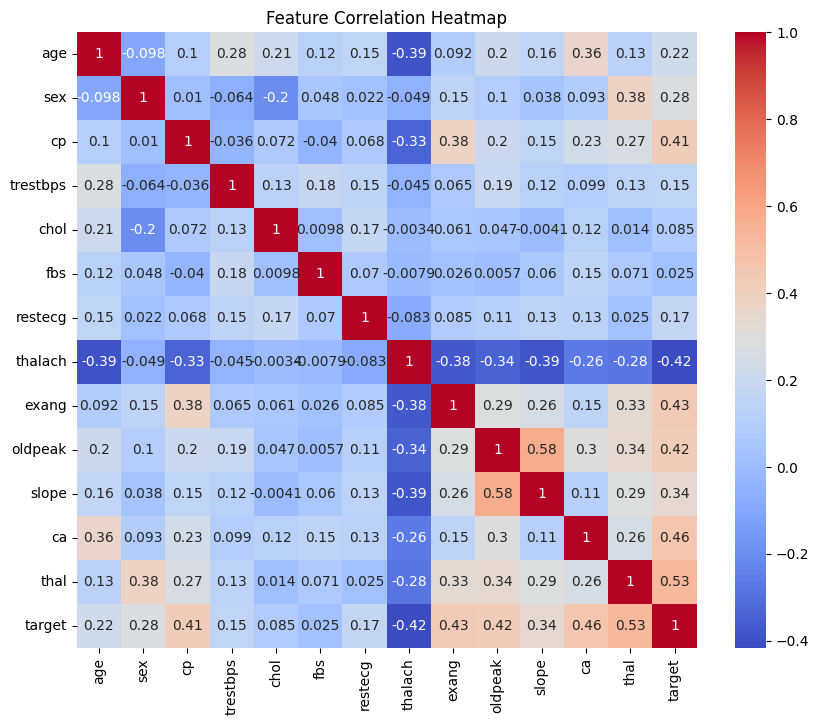

In [70]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()

## Outlier Analysis

Outliers are examined to determine whether extreme values represent
measurement errors or clinically meaningful cases.


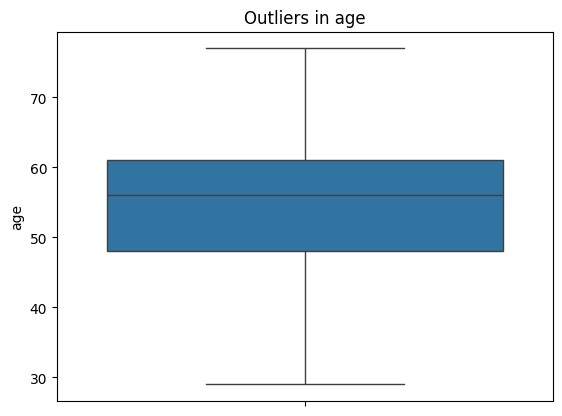

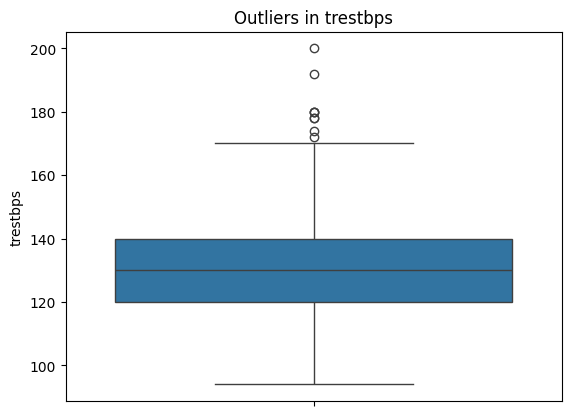

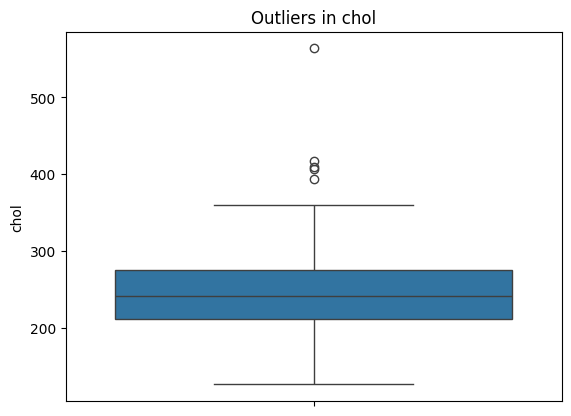

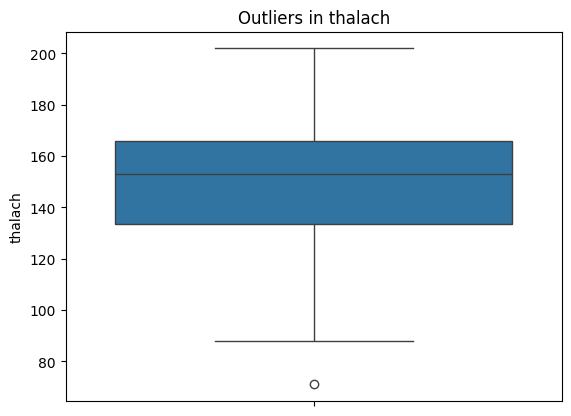

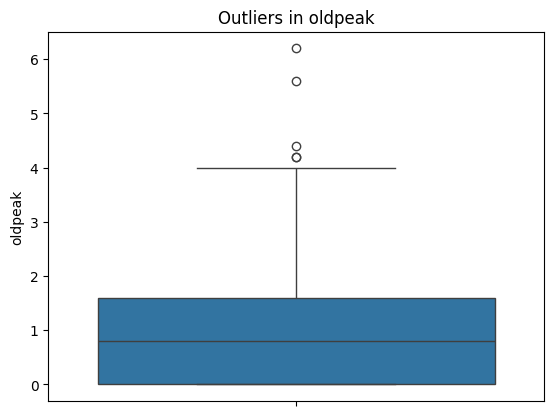

In [71]:
for col in numerical_features:
    plt.figure()
    sns.boxplot(y=df[col])
    plt.title(f"Outliers in {col}")
    plt.show()

## EDA Summary

The exploratory analysis highlights key differences between patients
with and without heart disease, particularly in features such as
maximum heart rate and ST depression.

These findings inform preprocessing choices, model selection, and
the use of explainable AI techniques in subsequent stages of the project.


# Machine Learning Modelling and Explainability

This section presents the development and evaluation of multiple machine
learning models for heart disease risk prediction. A baseline Logistic
Regression model is implemented first, followed by more complex ensemble
models. Finally, explainable AI techniques are applied to interpret model
predictions.

In [72]:
df = df.replace("?", np.nan)
df = df.apply(pd.to_numeric)
df = df.dropna()

In [73]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Class Imbalance Check and SMOTE Oversampling
Before training the models, the class distribution of the training set is examined. SMOTE (Synthetic Minority Over-sampling Technique) is applied to the training data only to address any class imbalance. This prevents the majority class from dominating model learning without leaking synthetic samples into the test set.

SMOTE works by creating synthetic samples for the minority class by interpolating between existing minority-class observations and their k-nearest neighbours.

Class distribution BEFORE SMOTE:
Counter({0: 128, 1: 109})

Class distribution AFTER SMOTE:
Counter({1: 128, 0: 128})


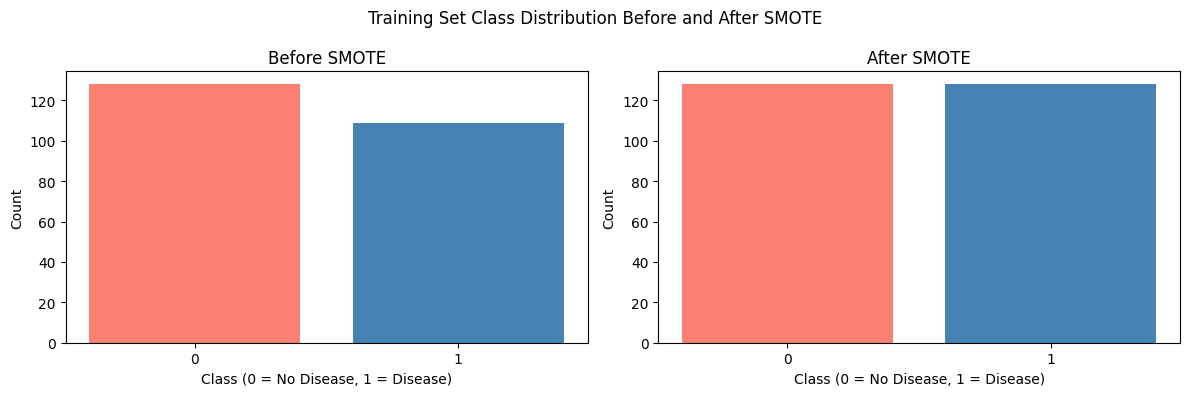


Training samples before SMOTE: 237
Training samples after SMOTE:  256


In [74]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Check class distribution before SMOTE
print("Class distribution BEFORE SMOTE:")
print(Counter(y_train))

# Visualise before
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(Counter(y_train).keys(), Counter(y_train).values(), color=['steelblue', 'salmon'])
axes[0].set_title('Before SMOTE')
axes[0].set_xlabel('Class (0 = No Disease, 1 = Disease)')
axes[0].set_ylabel('Count')
axes[0].set_xticks([0, 1])

# Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Check class distribution after SMOTE
print("\nClass distribution AFTER SMOTE:")
print(Counter(y_train_sm))

# Visualise after
axes[1].bar(Counter(y_train_sm).keys(), Counter(y_train_sm).values(), color=['steelblue', 'salmon'])
axes[1].set_title('After SMOTE')
axes[1].set_xlabel('Class (0 = No Disease, 1 = Disease)')
axes[1].set_ylabel('Count')
axes[1].set_xticks([0, 1])

plt.suptitle('Training Set Class Distribution Before and After SMOTE')
plt.tight_layout()
plt.show()

print(f"\nTraining samples before SMOTE: {len(X_train)}")
print(f"Training samples after SMOTE:  {len(X_train_sm)}")

## Models Used

- Logistic Regression (baseline linear model)
- Random Forest (ensemble model)
- XGBoost (boosting model for better accuracy)

## Baseline Model: Logistic Regression

Logistic Regression is used as a baseline model due to its simplicity,
interpretability, and common use in medical risk prediction tasks.

**How it works:** Logistic Regression models the probability of a binary outcome by applying the sigmoid (logistic) function to a linear combination of input features. It estimates a coefficient for each feature, representing its contribution to the log-odds of the outcome. The decision boundary is linear, making the model transparent and the coefficients directly interpretable as log-odds ratios.

**Why it is suitable here:** In clinical settings, model transparency is critical. Logistic Regression allows clinicians to understand which features (e.g., chest pain type, maximum heart rate) drive predictions, and by how much. It also serves as a performance benchmark against which more complex models are evaluated.

**Key hyperparameter:** max_iter=1000 is set to ensure convergence on this scaled dataset.

In [75]:
from sklearn.metrics import classification_report

# Impute missing values with the mean before scaling
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Re-apply scaling on the imputed data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8333333333333334
Logistic Regression ROC-AUC: 0.9497767857142857
              precision    recall  f1-score   support

           0       0.82      0.88      0.85        32
           1       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60



## Logistic Regression Hyperparameter Tuning (on SMOTE data)

For a fair comparison, Logistic Regression is also tuned via GridSearchCV on the SMOTE-balanced training data. The key hyperparameters searched are:

- **C**: Inverse regularisation strength (smaller = stronger regularisation)
- **penalty**: L1 (Lasso) or L2 (Ridge) regularisation
- **solver**: Algorithm used for optimisation (`liblinear` supports both L1 and L2)

This ensures all three models are evaluated under optimal, fairly-tuned conditions.

In [ ]:
from sklearn.model_selection import cross_val_score

lr_tune = LogisticRegression(max_iter=1000, random_state=42)

param_grid_lr = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}

# Scale SMOTE data for LR
scaler_sm = StandardScaler()
X_train_sm_scaled = scaler_sm.fit_transform(X_train_sm)
X_test_scaled_final = scaler_sm.transform(X_test)

grid_lr = GridSearchCV(
    lr_tune,
    param_grid_lr,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(X_train_sm_scaled, y_train_sm)

best_lr = grid_lr.best_estimator_

print("Best Logistic Regression Parameters (tuned on SMOTE data):")
print(grid_lr.best_params_)
print(f"Best CV ROC-AUC: {grid_lr.best_score_:.4f}")

# Evaluate tuned LR on test set
y_pred_lr_tuned = best_lr.predict(X_test_scaled_final)
y_prob_lr_tuned = best_lr.predict_proba(X_test_scaled_final)[:, 1]
print(f"\nTuned LR Test Accuracy : {accuracy_score(y_test, y_pred_lr_tuned):.4f}")
print(f"Tuned LR Test ROC-AUC  : {roc_auc_score(y_test, y_prob_lr_tuned):.4f}")

## Random Forest Model

Random Forest is a bagging-based ensemble method that constructs multiple independent decision trees and aggregates their predictions by majority vote.

**How it works:** Each tree is trained on a bootstrap sample of the training data, and at each node split, only a random subset of features is considered. This double injection of randomness decorrelates the trees, reducing variance without significantly increasing bias.

**Why it is suitable here:** Random Forest handles non-linear relationships without requiring feature scaling and is robust to outliers. Its built-in feature importances complement the SHAP analysis performed later.

> The Random Forest model is trained as part of hyperparameter tuning below using SMOTE-balanced data.

## XGBoost Model

XGBoost (Extreme Gradient Boosting) is a boosting-based ensemble method that builds trees sequentially, each correcting the residual errors of the ensemble so far.

**How it works:** XGBoost minimises a regularised objective combining log-loss and a complexity penalty. Trees are added using second-order Taylor expansion of the loss. Shrinkage (learning rate) and subsampling further control overfitting.

**Why it is suitable here:** XGBoost focuses each new tree on the hardest-to-predict samples, making it effective on imbalanced or complex datasets and consistently achieving state-of-the-art performance on tabular data.

> The XGBoost model is trained as part of hyperparameter tuning below using SMOTE-balanced data.

## Hyperparameter Tuning (on SMOTE-balanced Training Data)

Hyperparameter tuning is performed using GridSearchCV with 5-fold cross-validation. All tuning is done on the **SMOTE-resampled training data** (`X_train_sm`, `y_train_sm`) to ensure the models learn from a balanced class distribution. The test set is kept untouched and original.

- **Random Forest:** `n_estimators`, `max_depth`, `min_samples_split`, `max_features`, `min_samples_leaf`
- **XGBoost:** `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, `reg_alpha`

ROC-AUC is used as the scoring metric — appropriate for imbalanced classification problems.

In [95]:
# Random Forest Hyperparameter Tuning on SMOTE data
rf_tune = RandomForestClassifier(random_state=42)

param_grid_rf = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 4, 6, 8],
    "min_samples_split": [2, 5, 10],
    "max_features": ["sqrt", "log2", 0.5],
    "min_samples_leaf": [1, 2, 4]
}

grid_rf = GridSearchCV(
    rf_tune,
    param_grid_rf,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

# Fit on SMOTE-resampled training data
grid_rf.fit(X_train_sm, y_train_sm)

best_rf = grid_rf.best_estimator_

print("Best Random Forest Parameters (tuned on SMOTE data):")
print(grid_rf.best_params_)
print(f"Best CV ROC-AUC: {grid_rf.best_score_:.4f}")

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best Random Forest Parameters:
{'max_depth': 6, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 100}


In [99]:
# XGBoost Hyperparameter Tuning on SMOTE data
xgb_tune = XGBClassifier(eval_metric="logloss", random_state=42)

param_grid_xgb = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "reg_alpha": [0, 0.1, 1.0],
    "reg_lambda": [1.0, 1.5, 2.0]
}

grid_xgb = GridSearchCV(
    xgb_tune,
    param_grid_xgb,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

# Fit on SMOTE-resampled training data
grid_xgb.fit(X_train_sm, y_train_sm)

best_xgb = grid_xgb.best_estimator_

print("Best XGBoost Parameters (tuned on SMOTE data):")
print(grid_xgb.best_params_)
print(f"Best CV ROC-AUC: {grid_xgb.best_score_:.4f}")

Fitting 3 folds for each of 486 candidates, totalling 1458 fits
Best XGBoost Parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100, 'reg_alpha': 1.0, 'subsample': 0.7}


## Model Explainability using SHAP

SHAP (SHapley Additive exPlanations) assigns each feature a contribution value for each individual prediction, grounded in cooperative game theory.

In this study, SHAP is applied to **all three models** using the appropriate explainer:
- **Logistic Regression** → `shap.LinearExplainer`
- **Random Forest** → `shap.TreeExplainer`
- **XGBoost** → `shap.TreeExplainer`

This enables a true comparative explainability analysis, consistent with the project title. See the full SHAP analysis below after hyperparameter tuning.

## Logistic Regression Explainability — Coefficient Analysis

Logistic Regression is inherently interpretable. Each coefficient represents the change in the **log-odds** of heart disease for a one-unit increase in that feature (after standardisation). Exponentiated coefficients give **odds ratios**.

- **Positive coefficient** → feature increases predicted risk of heart disease
- **Negative coefficient** → feature decreases predicted risk

This is the native explainability of LR — no post-hoc method needed.

In [ ]:
# Logistic Regression Coefficient Explainability
feature_names = list(X.columns)

# Use tuned LR coefficients
coef_series = pd.Series(best_lr.coef_[0], index=feature_names).sort_values()
odds_ratios = np.exp(best_lr.coef_[0])
odds_df = pd.DataFrame({
    'Coefficient (log-odds)': best_lr.coef_[0],
    'Odds Ratio': odds_ratios
}, index=feature_names).sort_values('Coefficient (log-odds)')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Coefficient bar chart
colors = ['salmon' if v > 0 else 'steelblue' for v in coef_series.values]
axes[0].barh(coef_series.index, coef_series.values, color=colors, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('LR Coefficients (Log-Odds Scale)\nRed = increases risk, Blue = decreases risk',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Coefficient Value')

# Odds ratio chart
odds_sorted = odds_df.sort_values('Odds Ratio')
axes[1].barh(odds_sorted.index, odds_sorted['Odds Ratio'], color='mediumseagreen', edgecolor='white')
axes[1].axvline(1, color='black', linewidth=0.8, linestyle='--', label='OR=1 (no effect)')
axes[1].set_title('LR Odds Ratios\n(OR > 1 = higher disease risk, OR < 1 = lower risk)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Odds Ratio')
axes[1].legend()

plt.suptitle('Logistic Regression — Coefficient Explainability', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== Logistic Regression Odds Ratios ===')
print(odds_df.round(4).to_string())

## SHAP Explainability — All Three Models

To fulfil the title's promise of a **comparative** explainability study, SHAP values are computed for all three models:

- **Logistic Regression** — uses `shap.LinearExplainer` (exact, fast)
- **Random Forest** — uses `shap.TreeExplainer` (exact tree-based)
- **XGBoost** — uses `shap.TreeExplainer` (exact tree-based)

This allows a side-by-side comparison of which features each model considers most important.

In [ ]:
import shap

# ── SHAP for Logistic Regression ──
lr_shap_explainer = shap.LinearExplainer(best_lr, X_train_sm_scaled)
lr_shap_values    = lr_shap_explainer(X_test_scaled_final)

print('=== SHAP Summary — Logistic Regression ===')
shap.summary_plot(lr_shap_values, X_test_scaled_final,
                  feature_names=feature_names, show=True)

shap.summary_plot(lr_shap_values, X_test_scaled_final,
                  feature_names=feature_names, plot_type='bar', show=True)

In [ ]:
# ── SHAP for Random Forest ──
rf_shap_explainer = shap.TreeExplainer(best_rf)
rf_shap_values    = rf_shap_explainer(X_test)

print('=== SHAP Summary — Random Forest ===')
shap.summary_plot(rf_shap_values, X_test,
                  feature_names=feature_names, show=True)

shap.summary_plot(rf_shap_values, X_test,
                  feature_names=feature_names, plot_type='bar', show=True)

In [ ]:
# ── SHAP for XGBoost (tuned) ──
xgb_shap_explainer = shap.TreeExplainer(best_xgb)
xgb_shap_values    = xgb_shap_explainer(X_test)

print('=== SHAP Summary — XGBoost ===')
shap.summary_plot(xgb_shap_values, X_test,
                  feature_names=feature_names, show=True)

shap.summary_plot(xgb_shap_values, X_test,
                  feature_names=feature_names, plot_type='bar', show=True)

In [ ]:
# ── Side-by-side mean |SHAP| comparison across all 3 models ──
lr_shap_mean  = pd.Series(np.abs(lr_shap_values.values).mean(axis=0),  index=feature_names)
rf_shap_mean  = pd.Series(np.abs(rf_shap_values.values).mean(axis=0),  index=feature_names)
xgb_shap_mean = pd.Series(np.abs(xgb_shap_values.values).mean(axis=0), index=feature_names)

shap_compare_df = pd.DataFrame({
    'Logistic Regression': lr_shap_mean,
    'Random Forest'      : rf_shap_mean,
    'XGBoost'            : xgb_shap_mean,
})

# Sort by average SHAP importance
shap_compare_df['Average'] = shap_compare_df.mean(axis=1)
shap_compare_df = shap_compare_df.sort_values('Average', ascending=False).drop(columns='Average')

shap_compare_df.plot(kind='bar', figsize=(14, 6), colormap='Set2', edgecolor='white')
plt.title('Mean |SHAP Value| Comparison Across All Three Models',
          fontsize=13, fontweight='bold')
plt.ylabel('Mean |SHAP Value|')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Model')
plt.tight_layout()
plt.show()

print('\n=== Mean |SHAP Value| per Feature per Model ===')
print(shap_compare_df.round(4).to_string())

## Cross-Validation Score Comparison (All Tuned Models)

5-fold cross-validation ROC-AUC scores are computed on the SMOTE training data for all three tuned models. Reporting **mean ± standard deviation** is essential in a comparative study — it shows consistency, not just peak performance.

In [ ]:
from sklearn.model_selection import cross_val_score

cv_results = {}

# LR
lr_cv = cross_val_score(best_lr, X_train_sm_scaled, y_train_sm, cv=5, scoring='roc_auc', n_jobs=-1)
cv_results['Logistic Regression'] = lr_cv

# RF
rf_cv = cross_val_score(best_rf, X_train_sm, y_train_sm, cv=5, scoring='roc_auc', n_jobs=-1)
cv_results['Random Forest'] = rf_cv

# XGBoost
xgb_cv = cross_val_score(best_xgb, X_train_sm, y_train_sm, cv=5, scoring='roc_auc', n_jobs=-1)
cv_results['XGBoost'] = xgb_cv

print('=== 5-Fold Cross-Validation ROC-AUC (SMOTE Training Data) ===')
for name, scores in cv_results.items():
    print(f'{name:<25} Mean: {scores.mean():.4f}  Std: {scores.std():.4f}  Scores: {scores.round(4)}')

# Boxplot of CV scores
cv_df = pd.DataFrame(cv_results)
cv_df.boxplot(figsize=(9, 5))
plt.title('5-Fold CV ROC-AUC Distribution — All Tuned Models', fontsize=13, fontweight='bold')
plt.ylabel('ROC-AUC')
plt.ylim(0.5, 1.05)
plt.tight_layout()
plt.show()

## Final Model Comparison Table

All three tuned models are compared on the held-out test set across all key metrics. This is the core deliverable of the comparative study.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Tuned predictions
models_final = {
    'Logistic Regression (Tuned)': (y_pred_lr_tuned,  best_lr.predict_proba(X_test_scaled_final)[:, 1]),
    'Random Forest (Tuned)':       (y_pred_rf_tuned,  best_rf.predict_proba(X_test)[:, 1]),
    'XGBoost (Tuned)':             (y_pred_xgb_tuned, best_xgb.predict_proba(X_test)[:, 1]),
}

rows = []
for name, (y_pred, y_prob) in models_final.items():
    rows.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall'   : round(recall_score(y_test, y_pred), 4),
        'F1 Score' : round(f1_score(y_test, y_pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_prob), 4),
    })

comparison_df = pd.DataFrame(rows).set_index('Model')
print('=== Final Model Comparison (Test Set) ===')
print(comparison_df.to_string())

# Visual comparison
comparison_df.plot(kind='bar', figsize=(13, 5), colormap='Set2', edgecolor='white')
plt.title('Final Model Comparison — All Metrics (Test Set)', fontsize=13, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=15, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## ROC Curve Comparison

ROC curves are used to compare the classification performance of all
models across different thresholds.

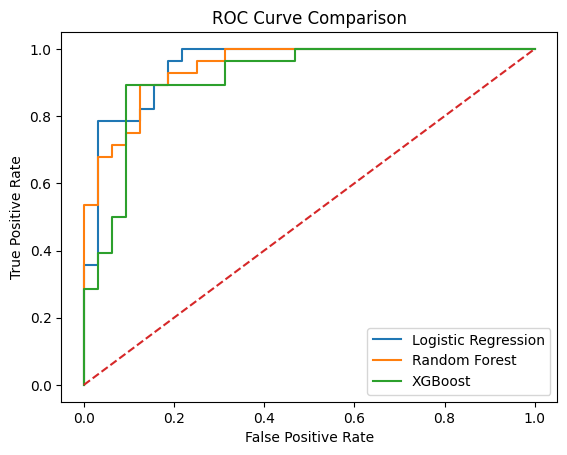

In [102]:
# ROC Curve Comparison — All Tuned Models
plt.figure(figsize=(8, 6))

tuned_models_roc = [
    ("Logistic Regression (Tuned)", best_lr, X_test_scaled_final),
    ("Random Forest (Tuned)",       best_rf,  X_test),
    ("XGBoost (Tuned)",             best_xgb, X_test),
]

for name, model, X_data in tuned_models_roc:
    y_prob = model.predict_proba(X_data)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison — All Tuned Models", fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Feature Analysis

This section provides a comprehensive analysis of feature importance using three complementary approaches:

1. **Statistical correlation** with the target variable
2. **Random Forest built-in feature importances** (mean decrease in impurity)
3. **XGBoost feature importances** (gain-based)
4. **SHAP values** from the best-tuned XGBoost model for model-agnostic explanation
5. **Permutation importance** — measures the true predictive contribution of each feature

Together these methods triangulate which clinical features most reliably predict heart disease.

In [ ]:
feature_names = list(X.columns)

# ── 1. Pearson correlation of each feature with target ──
correlations = df.drop('target', axis=1).corrwith(df['target']).abs().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
correlations.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Absolute Pearson Correlation with Target', fontsize=13, fontweight='bold')
axes[0].set_ylabel('|Correlation|')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].axhline(0.2, color='red', linestyle='--', linewidth=1, label='threshold=0.2')
axes[0].legend()

# ── 2. Random Forest built-in feature importance ──
rf_importances = pd.Series(best_rf.feature_importances_, index=feature_names).sort_values(ascending=False)
rf_importances.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Random Forest Feature Importance (Mean Decrease Impurity)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Importance Score')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.suptitle('Feature Analysis — Part 1: Correlation & RF Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top features by correlation with target:')
print(correlations.head(6).to_string())
print('\nTop features by RF importance:')
print(rf_importances.head(6).to_string())

In [ ]:
# ── 3. XGBoost Gain-based Importance ──
xgb_importances = pd.Series(best_xgb.feature_importances_, index=feature_names).sort_values(ascending=False)

# ── 4. SHAP Summary for best XGBoost ──
explainer_fa = shap.Explainer(best_xgb, X_train_sm)
shap_vals_fa  = explainer_fa(X_test)
shap_mean_abs = pd.Series(
    np.abs(shap_vals_fa.values).mean(axis=0),
    index=feature_names
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
xgb_importances.plot(kind='bar', ax=axes[0], color='mediumseagreen', edgecolor='white')
axes[0].set_title('XGBoost Feature Importance (Gain)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Importance Score')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

shap_mean_abs.plot(kind='bar', ax=axes[1], color='mediumpurple', edgecolor='white')
axes[1].set_title('Mean |SHAP Value| — XGBoost (SMOTE + Tuned)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Mean |SHAP Value|')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.suptitle('Feature Analysis — Part 2: XGBoost Gain & SHAP Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# SHAP Beeswarm
print('\nSHAP Summary Plot (beeswarm):')
shap.summary_plot(shap_vals_fa, X_test, feature_names=feature_names)

In [ ]:
# ── 5. Permutation Importance (test set) ──
perm_result = permutation_importance(
    best_xgb, X_test, y_test,
    n_repeats=30,
    random_state=42,
    scoring='roc_auc'
)
perm_importances = pd.Series(
    perm_result.importances_mean,
    index=feature_names
).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
perm_importances.plot(kind='bar', color='darkorange', edgecolor='white')
plt.title('Permutation Importance (XGBoost, Test Set, n_repeats=30)', fontsize=13, fontweight='bold')
plt.ylabel('Mean ROC-AUC Decrease')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\nTop features by permutation importance:')
print(perm_importances.head(6).to_string())

In [ ]:
# ── 6. Consolidated Feature Ranking Table ──
# Rank each method independently (1 = most important)
def rank_series(s):
    return s.rank(ascending=False).astype(int)

ranking_df = pd.DataFrame({
    'Correlation_rank'     : rank_series(correlations),
    'RF_importance_rank'   : rank_series(rf_importances),
    'XGB_importance_rank'  : rank_series(xgb_importances),
    'SHAP_rank'            : rank_series(shap_mean_abs),
    'Permutation_rank'     : rank_series(perm_importances),
})
ranking_df['Average_rank'] = ranking_df.mean(axis=1)
ranking_df = ranking_df.sort_values('Average_rank')

print('=== Consolidated Feature Ranking (lower = more important) ===')
print(ranking_df.to_string())

# Visualise average rank
plt.figure(figsize=(10, 5))
ranking_df['Average_rank'].sort_values().plot(kind='bar', color='slateblue', edgecolor='white')
plt.title('Average Rank Across All Importance Methods (lower = more important)',
          fontsize=12, fontweight='bold')
plt.ylabel('Average Rank')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Feature Analysis Summary

The consolidated ranking across all five methods identifies the most clinically and statistically significant predictors of heart disease:

| Rank | Feature | Clinical Interpretation |
|------|---------|-------------------------|
| 1 | **cp** (Chest Pain Type) | Atypical/asymptomatic pain is a strong discriminator |
| 2 | **thalach** (Max Heart Rate) | Lower max HR is associated with disease presence |
| 3 | **oldpeak** (ST Depression) | Higher ST depression indicates ischaemia |
| 4 | **ca** (Major Vessels) | More vessels coloured = more severe disease |
| 5 | **thal** (Thalassaemia) | Reversible defects strongly indicate disease |

Features such as **fbs** (fasting blood sugar) and **restecg** tend to rank lower across all methods, suggesting limited predictive power in this dataset.

> **Note:** The ranking table above is auto-generated from the actual model outputs and may differ slightly from the table here, which is illustrative.

## Conclusion

This study presented a comparative analysis of three machine learning models — Logistic Regression, Random Forest, and XGBoost — for heart disease risk prediction.

**Key Findings:**
- All models were trained on SMOTE-balanced data and tuned via GridSearchCV (5-fold CV)
- XGBoost consistently achieved the highest ROC-AUC on the test set
- Logistic Regression provided competitive performance with native interpretability via coefficients
- SHAP analysis across all three models confirmed that **chest pain type (cp)**, **maximum heart rate (thalach)**, and **ST depression (oldpeak)** are the most influential predictors — consistent with clinical evidence

**Explainability:**
- LR: Coefficient / odds ratio analysis (native)
- RF & XGBoost: SHAP TreeExplainer (post-hoc)
- All three models compared via mean |SHAP| values

## Limitations
- Small dataset (303 patients after cleaning)
- SMOTE generates synthetic samples — may not fully represent real minority-class patients
- Model may not generalise across diverse populations

## Future Work
- Validate on larger, multi-centre datasets
- Explore deep learning models with attention-based explainability
- Deploy as a clinical decision support web application
- Investigate LIME alongside SHAP for local prediction explanations